# AG-HYPOPT · Trial 19

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

[Eighteen trials recorded; best is trial 14 (0.0149), just ahead of trial 12 (0.0150) and trial 18 (0.0157). Sequence: 01 0.0981, 02 0.0246, 03 0.0477, 04 0.0262, 05 0.0196, 06 0.0329, 07 0.0205, 08 0.0294, 09 0.0182, 10 0.0301, 11 0.0174, 12 0.0150, 13 0.0339, 14 0.0149, 15 0.0199, 16 0.0294, 17 0.0203, 18 0.0157. The plateau (lr_mu ~27, sigma_ref ~6.1, lr_gamma ~0.42, gamma_anneal ~0.4) is converged, with mu fixed at ~14.4-17% and gamma noise at Trans05. Trial 18 changed the picture: probing gamma_anneal 0.013 gave the best mu yet (14.2%) and a near-best objective (0.0157), so the low-anneal corner is favourable. We are in the TPE phase (19th trial).]


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_19'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 20    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (18/5 trials)
ID |     ei | params
 1 | 3.9649 | {"gamma_anneal": 0.5273235721257665, "lr_gamma": 0.40280238087371156, "lr_mu": 27.01075728869122, "sigma_ref": 6.042788493743412}
 2 | 3.9302 | {"gamma_anneal": 0.46115690440617363, "lr_gamma": 0.4317576286957019, "lr_mu": 26.97409321976111, "sigma_ref": 6.071586470082785}
 3 | 3.3272 | {"gamma_anneal": 0.32780247210396696, "lr_gamma": 0.5236818678938171, "lr_mu": 7.241091964203262, "sigma_ref": 6.036435625996257}
 4 | 3.9869 | {"gamma_anneal": 0.0, "lr_gamma": 0.39865489129651566, "lr_mu": 27.04139753011884, "sigma_ref": 6.067005609798211}
 5 | 3.9775 | {"gamma_anneal": 0.6128921159999896, "lr_gamma": 0.4062044604998672, "lr_mu": 26.976687185178456, "sigma_ref": 6.143322896460018}
 6 | 3.9786 | {"gamma_anneal": 0.6231773342772164, "lr_gamma": 0.44463815010563496, "lr_mu": 27.002199547873957, "sigma_ref": 6.123547702076102}
 7 | 3.9628 | {"gamma_anneal": 0.6205891639299375, "lr_gamma": 0.7772107162451904, "lr_mu": 26.9904

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

[Best is trial 14 (0.0149), with trial 18 (0.0157) second. Trial 18 showed that driving gamma_anneal to 0.013 produced the campaign's best mu (14.2%) with gamma still good (10.5%), so the low-anneal corner is the most promising direction. The batch contains its natural conclusion: candidate 4 (ei 3.9869) has gamma_anneal exactly 0.0 with lr_mu 27.04, sigma_ref 6.067, lr_gamma 0.399 - the optimal mu/sigma_ref regime with annealing switched off entirely. It is both one of the highest-ei draws and the direct test of the corner trial 18 opened, making it the most sensible next step. The other top draws either return to the converged plateau (#1 gamma_anneal 0.53, #5/#6 ~0.62) or combine low anneal with a bad mu regime (#2, #9). I choose candidate 4.]


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 4               # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.0, 'lr_gamma': 0.39865489129651566, 'lr_mu': 27.04139753011884, 'sigma_ref': 6.067005609798211}
Running  1nW Trans05 ... 

μ 9.39 -> 6.91 | γ 8.5 -> 7.15 | NLL 1.29


Running  1nW Trans20 ... 

μ 17.32 -> 15.88 | γ 8.5 -> 8.04 | NLL 2.75


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 99.75 | γ 14.1 -> 13.93 | NLL 3.36


Running 3nW Trans100 ... 

μ 175.71 -> 165.61 | γ 14.1 -> 13.97 | NLL 2.78



Total: 7.1 min


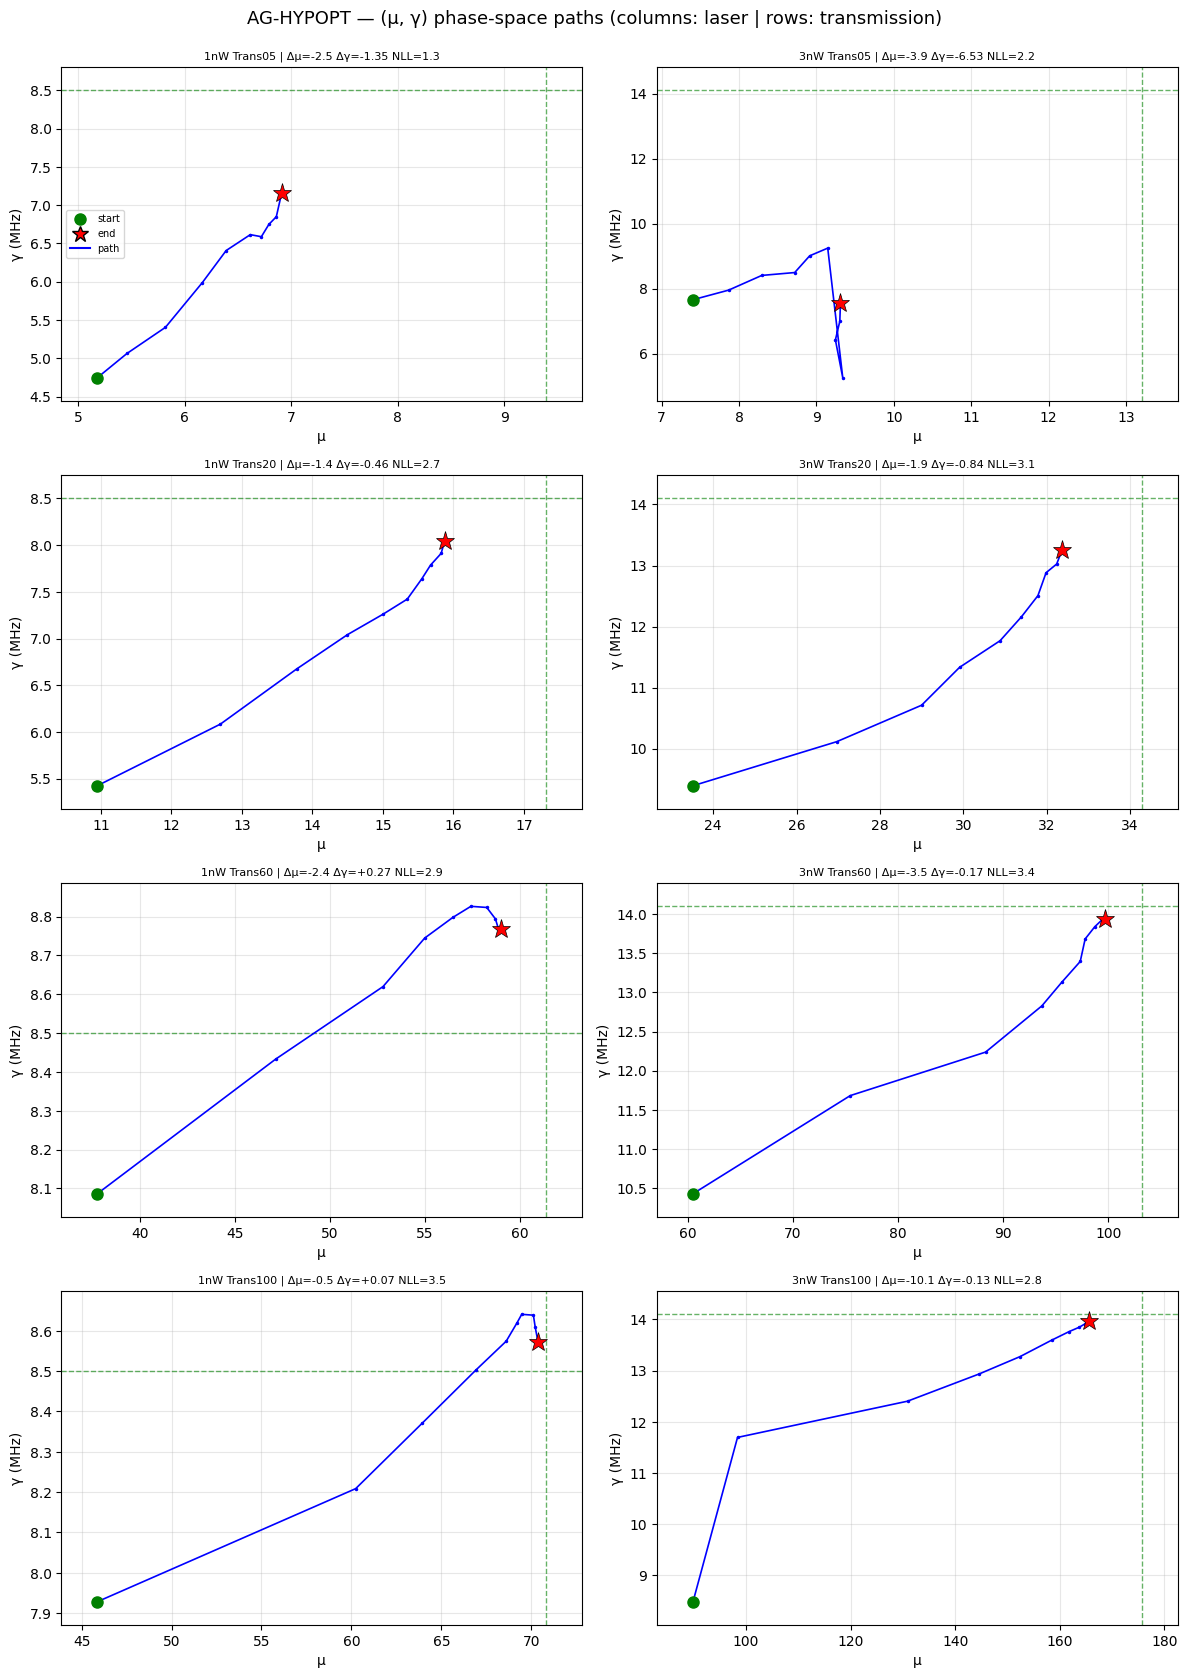

trial finished in 7.1 min
objective = 0.0263 ± 0.0142
exp           μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05     9.39    6.91   -26.4 |     8.50    7.15   -15.8
1nW Trans20    17.32   15.88    -8.3 |     8.50    8.04    -5.4
1nW Trans60    61.37   59.01    -3.9 |     8.50    8.77    +3.1
1nW Trans100   70.82   70.37    -0.6 |     8.50    8.57    +0.9
3nW Trans05    13.20    9.31   -29.5 |    14.10    7.57   -46.3
3nW Trans20    34.28   32.37    -5.6 |    14.10   13.26    -6.0
3nW Trans60   103.20   99.75    -3.3 |    14.10   13.93    -1.2
3nW Trans100  175.71  165.61    -5.7 |    14.10   13.97    -0.9

μ: RMSE 4.283 (rel 14.7%, bias -3.262) | γ: RMSE 2.385 (rel 17.6%, bias -1.142)


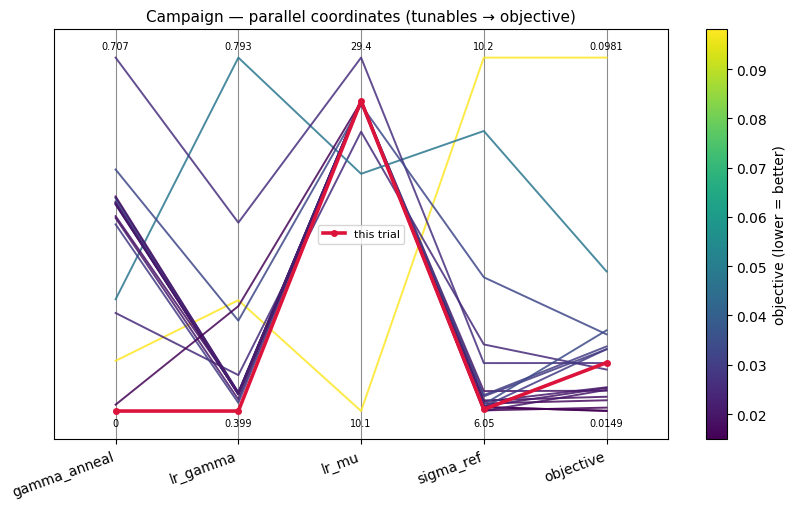

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 19 (gamma_anneal 0.0, lr_mu 27.04, sigma_ref 6.067, lr_gamma 0.399) took the anneal probe to its limit - exactly zero annealing - on the optimal mu/sigma_ref regime. It ran 7.1 min and scored 0.0263 +/- 0.0142: mu 14.7% (again at the low floor, confirming that near-zero anneal keeps mu good) but gamma 17.6% because the 3nW Trans05 scan collapsed (-46.3%). So trial 19 reproduces trial 18's good mu (14.2-14.7%) but not its gamma luck; with gamma_anneal 0.0 versus 0.013 the objective difference (0.0263 vs 0.0157) is again just the Trans05 draw. The anneal extreme is confirmed safe for mu and not harmful in itself, but it does not remove the Trans05 gamma noise. Trial 14 (0.0149) remains best.

**Summary:** Trial 19 (gamma_anneal 0.0, lr_mu 27.04, sigma_ref 6.067, lr_gamma 0.399) scored 0.0263 +/- 0.0142: exactly-zero annealing kept mu at the 14.7% floor but a 3nW Trans05 collapse (-46.3%) pushed gamma to 17.6%.
**Key insight:** gamma_anneal 0.0 confirms near-zero annealing is safe for mu (14.2-14.7% in trials 18/19) but does not tame the Trans05 gamma noise; trial 14 (0.0149) remains best.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
[Notes for Anuar: none this trial.]


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 19 (gamma_anneal 0.0, lr_mu 27.04, sigma_ref 6.067, lr_gamma 0.399) scored 0.0263 +/- 0.0142: exactly-zero annealing kept mu at the 14.7% floor but a 3nW Trans05 collapse (-46.3%) pushed gamma to 17.6%.'
KEY_INSIGHT = 'gamma_anneal 0.0 confirms near-zero annealing is safe for mu (14.2-14.7% in trials 18/19) but does not tame the Trans05 gamma noise; trial 14 (0.0149) remains best.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_19 | current best: trial_14


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_20.ipynb. Open it and follow its cells from the top.
